# Soluções dos Exercícios de Ray-Tracing e Propagação

Para a resolução dos exercícios deste capítulo, recomendamos a utilização da função [minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) do pacote [SciPy](https://scipy.org/pt/). Recomendamos também os pacotes [Numpy](https://numpy.org/) e [Matplotlib](https://matplotlib.org/), que serão amplamente utilizados no decorrer do curso.

## Exercício 1

**Passo 1:** Importar os pacotes necessários;

In [1]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

**Passo 2:** Definir as variáveis necessárias;

In [2]:
e = np.array([-3., 0.5])
r = np.array([2., 0.])
c = 1480.

**Passo 3:** Definir a função que calcula o tempo de voo;

In [3]:
def tof(x, args):
    e, r, c = args
    dist1 = np.sqrt((x - e[0])**2 + (1 - e[1])**2)
    dist2 = np.sqrt((r[0] - x)**2 + (r[1] - 1)**2)
    return (dist1 + dist2)/c

**Passo 4:** Ache o ponto de intersecção na reta que minimiza o tempo de voo;

In [4]:
result = minimize(tof, 2, [e, r, c])
print(result)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.003528208767519277
        x: [-1.116e+00]
      nit: 6
      jac: [ 9.709e-06]
 hess_inv: [[ 1.742e+04]]
     nfev: 22
     njev: 11


**Passo 5:** Plote o gráfico com a solução;

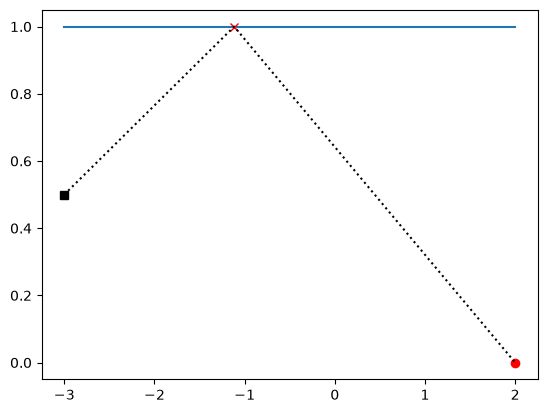

In [5]:
plt.plot(e[0], e[1], 'sk')
plt.plot(r[0], r[1], 'or')
plt.plot([-3., 2.], [1., 1.])

p = np.array([result.x[0], 1.])

plt.plot(p[0], p[1], 'xr')
plt.plot([e[0], p[0], r[0]], [e[1], p[1], r[1]], 'k:')

**Passo 6:** Compare os ângulos.

In [6]:
alpha = np.arctan((e[0] - p[0])/(e[1] - p[1]))
beta = np.arctan((r[0] - p[0])/(r[1] - p[1]))

print(alpha)
print(beta)

1.3113756170341853
-1.2602608794877712


Discuta o resultado com seu orientador.

## Exercício 2

**Passo 1:** Importar os pacotes necessários;

In [7]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

**Passo 2:** Definir as variáveis necessárias;

In [8]:
e = np.array([-3., 3])
r = np.array([2., 0.])
c1 = 1480.
c2 = 6400.

**Passo 3:** Definir a função que calcula o tempo de voo;

In [9]:
def tof(x, args):
  e, r, c1, c2 = args
  dist1 = np.sqrt((x - e[0])**2 + (1 - e[1])**2)
  dist2 = np.sqrt((r[0] - x)**2 + (r[1] - 1)**2)
  return dist1/c1 + dist2/c2

**Passo 4:** Ache o ponto de intersecção na reta que minimiza o tempo de voo;

In [10]:
result = minimize(tof, 2, [e, r, c1, c2])
print(result)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0021130152886794443
        x: [-2.531e+00]
      nit: 5
      jac: [ 1.588e-06]
 hess_inv: [[ 3.241e+03]]
     nfev: 24
     njev: 12


**Passo 5:** Plote o gráfico com a solução;

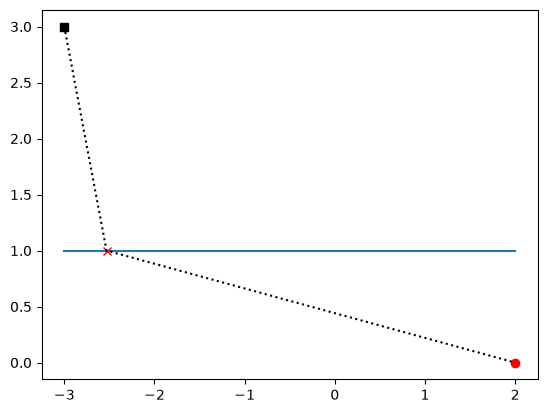

In [11]:
plt.plot(e[0], e[1], 'sk')
plt.plot(r[0], r[1], 'or')
plt.plot([-3., 2.], [1., 1.])

p = np.array([result.x[0], 1.])

plt.plot(p[0], p[1], 'xr')
plt.plot([e[0], p[0], r[0]], [e[1], p[1], r[1]], 'k:')

**Passo 6:** Compare os ângulos.

In [12]:
seno_theta = (e[0] - p[0])/np.linalg.norm(e - p)
seno_phi = (r[0] - p[0])/np.linalg.norm(r - p)

print(c2*seno_theta)
print(c1*seno_phi)

-1460.266664241401
1445.2251370726606


Discuta o resultado com seu orientador.

## Exercício 3.1

**Passo 1:** Importar os pacotes necessários;

In [13]:
import numpy as np
import matplotlib.pyplot as plt

**Passo 2:** Definir as variáveis necessárias;

In [14]:
e = np.array([-3., 0.5])
r = np.array([2., 0.])
c = 1480.

**Passo 3:** Definir as seguintes funções de conveniência;

In [15]:
def uhp(x):
    x = np.mod(x, np.pi)
    return x

def rhp(x):
    x = uhp(x)
    x = x - (x > np.pi / 2) * np.pi
    x = x + (x < -np.pi / 2) * np.pi
    return x

**Passo 4:** Definir o kernel de distância:

In [16]:
def dist_kernel(x, args):
    e, r, c = args
    p = np.array([x, 1]);
    inc_ang = np.arctan((p[1] - e[1])/(p[0] - e[0]))
    ref_ang = rhp(inc_ang - np.pi)
    a1 = np.tan(ref_ang)
    b1 = p[1] - a*p[0]
    a2 = -1/a1
    b2 = r[1] - a2*r[0]
    r_in = np.array([(b2 - b1)/(a1 - a2), a_1 * x_in + b1])
    dist = (r_in[0] - r[0])**2 + (r_in[1] - r[1])**2
    return dist, r_in